In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:


df=pd.read_csv('german_credit_data.csv')
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [7]:
df=df.dropna().reset_index(drop=True)

In [8]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [9]:
df.drop(columns='Unnamed: 0',inplace= True)

In [10]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

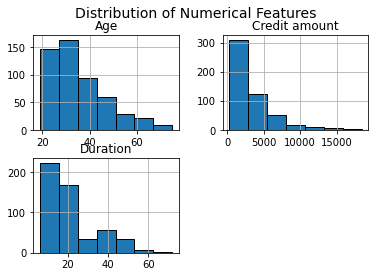

In [11]:
df[["Age","Credit amount","Duration"]].hist(bins=7, edgecolor="black")
plt.suptitle("Distribution of Numerical Features",fontsize=14)
plt.show()

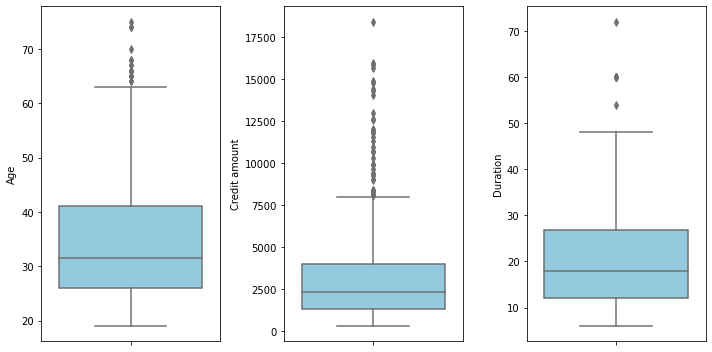

In [12]:
plt.figure(figsize=(10,5))
for i, col in enumerate(["Age","Credit amount","Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=df[col],color="skyblue")
plt.tight_layout()
plt.show()    

In [13]:
categorical_cols=["Sex","Job","Housing","Saving accounts","Checking account","Purpose"]

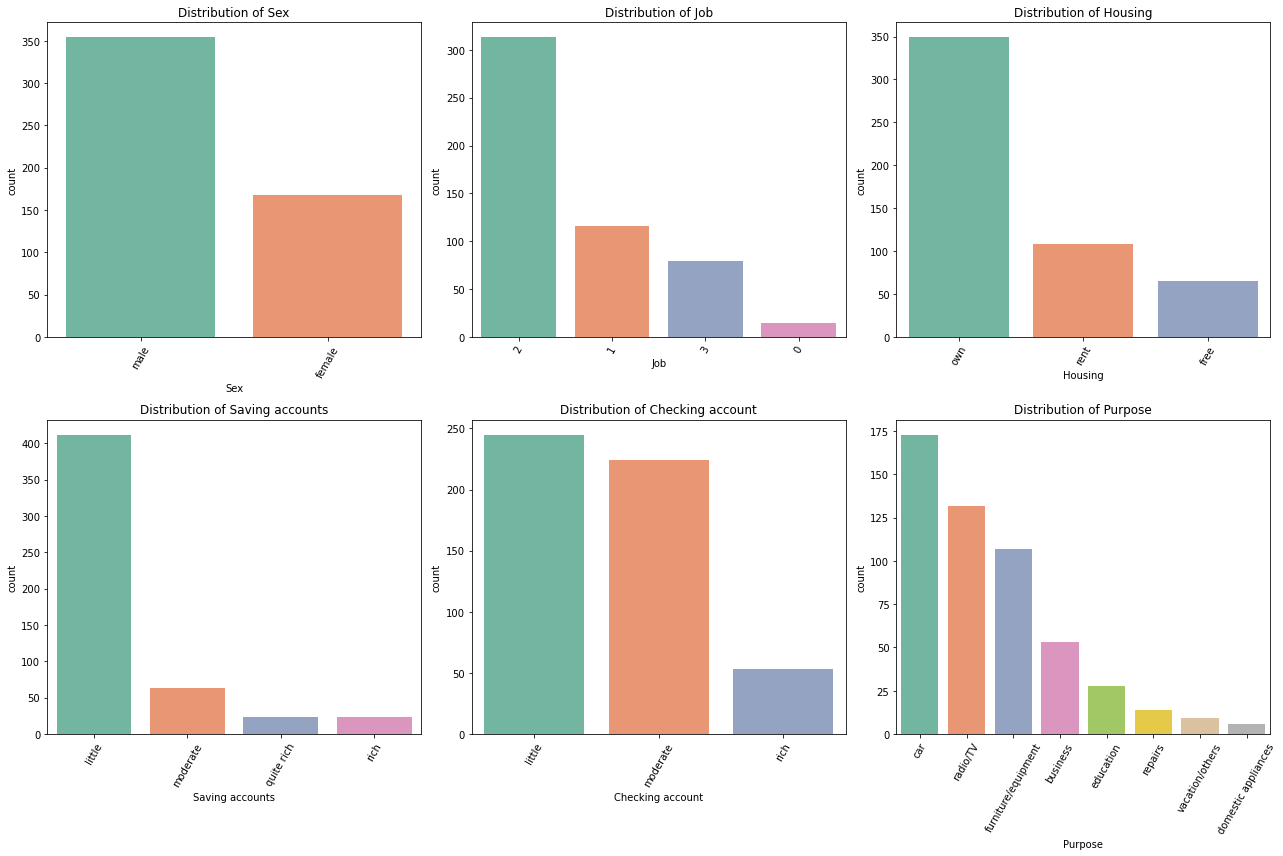

In [14]:
plt.figure(figsize=(18, 12))

for i, col in enumerate(categorical_cols):
    plt.subplot(2,3,i+1)
    sns.countplot(
        data=df,
        x=col,
        palette="Set2",
        order=df[col].value_counts().index
    )
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=60)

plt.tight_layout()
plt.show() 

In [15]:
corr=df[["Age","Job","Credit amount","Duration"]].corr()

In [16]:
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


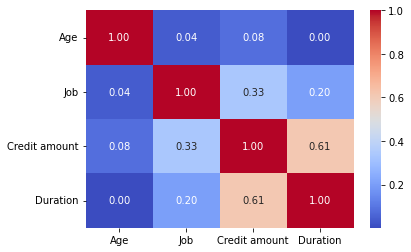

In [17]:
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.show()

In [18]:
df.groupby("Job")["Credit amount"].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [19]:
df.groupby("Sex")["Credit amount"].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [20]:
pd.pivot_table(df,values="Credit amount",index="Housing",columns="Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


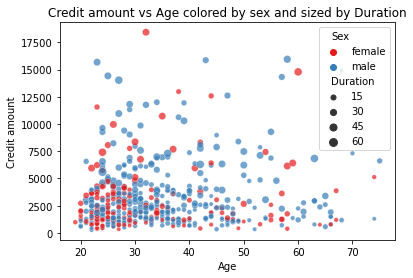

In [21]:
sns.scatterplot(data=df,x="Age",y="Credit amount",hue="Sex",size="Duration",alpha=0.7,palette="Set1")
plt.title("Credit amount vs Age colored by sex and sized by Duration")
plt.show()

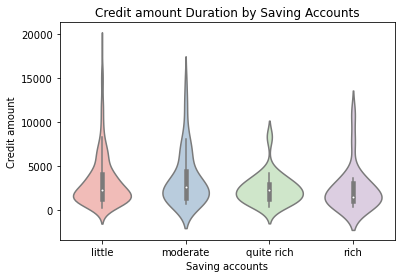

In [22]:
sns.violinplot(data=df,x="Saving accounts",y="Credit amount",palette="Pastel1")
plt.title("Credit amount Duration by Saving Accounts")
plt.show()

In [23]:
df["Risk"].value_counts(normalize=True)*100

good    55.747126
bad     44.252874
Name: Risk, dtype: float64

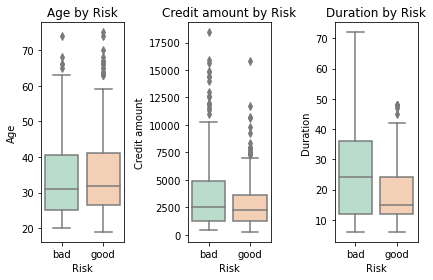

In [24]:
for i, col in enumerate(["Age","Credit amount","Duration"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df,x="Risk",y=col,palette="Pastel2")
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()    

In [25]:
df.groupby("Risk")[["Age","Credit amount","Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


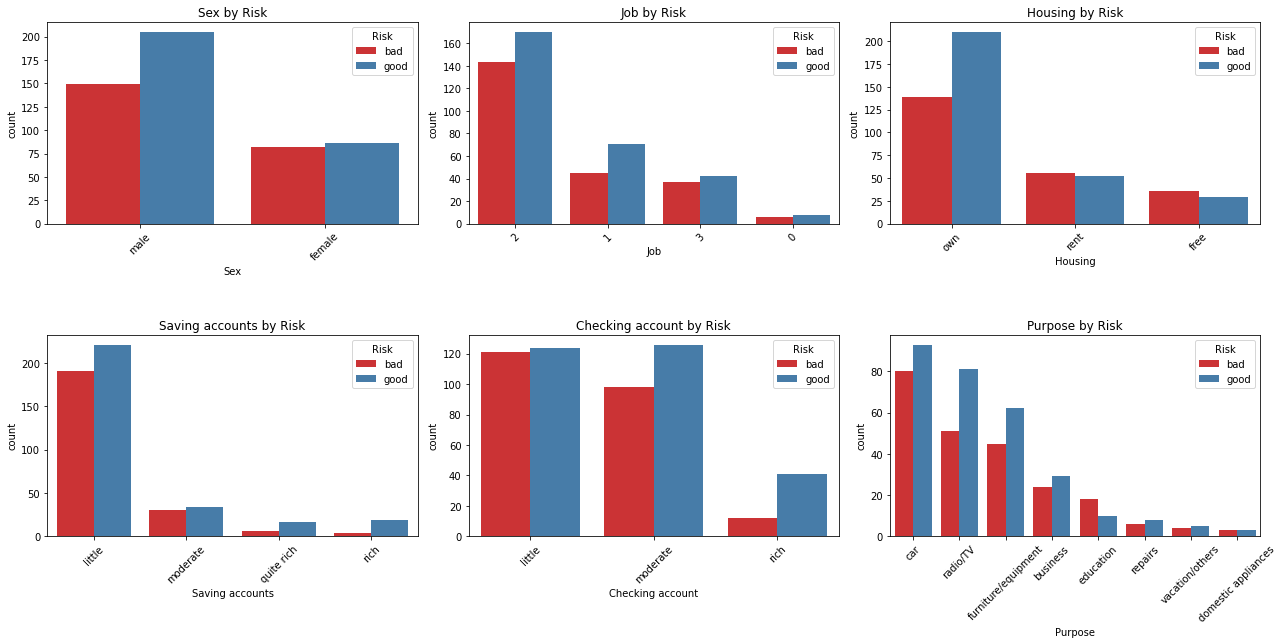

In [26]:
plt.figure(figsize=(18, 12))

for i, col in enumerate(categorical_cols):
    plt.subplot(3,3,i+1)
    sns.countplot(data=df,x=col,hue="Risk",palette="Set1",order=df[col].value_counts().index
    )
    plt.title(f"{col} by Risk")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show() 

In [27]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [28]:
features=["Age", "Sex", "Job", "Housing", "Saving accounts", "Checking account",
       "Credit amount", "Duration"]

In [29]:
target="Risk"

In [30]:
df_model=df[features+[target]].copy()

In [31]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,female,2,own,little,moderate,5951,48,bad
1,45,male,2,free,little,little,7882,42,good
2,53,male,2,free,little,little,4870,24,bad
3,35,male,3,rent,little,moderate,6948,36,good
4,28,male,3,own,little,moderate,5234,30,bad


In [32]:
from sklearn.preprocessing import LabelEncoder
import joblib


In [33]:
cat_cols=df_model.select_dtypes(include="object").columns.drop("Risk")

In [34]:
le_dict={}

In [35]:
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account'], dtype='object')

In [36]:
for col in cat_cols:
    le=LabelEncoder()
    df_model[col]=le.fit_transform(df_model[col])
    le_dict[col]=le
    joblib.dump(le,f"{col}_encoder.pkl")

In [37]:
le_target=LabelEncoder()

In [38]:
target

'Risk'

In [39]:
df_model[target]=le_target.fit_transform(df_model[target])

In [40]:
df_model[target].value_counts()

1    291
0    231
Name: Risk, dtype: int64

In [41]:
joblib.dump(le_target,"target_encoder.pkl")

['target_encoder.pkl']

In [42]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Risk
0,22,0,2,1,0,1,5951,48,0
1,45,1,2,0,0,0,7882,42,1
2,53,1,2,0,0,0,4870,24,0
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,0


In [43]:
from sklearn.model_selection import train_test_split

In [44]:
x=df_model.drop(target,axis=1)

In [45]:
y=df_model[target]

In [46]:
x

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration
0,22,0,2,1,0,1,5951,48
1,45,1,2,0,0,0,7882,42
2,53,1,2,0,0,0,4870,24
3,35,1,3,2,0,1,6948,36
4,28,1,3,1,0,1,5234,30
...,...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743,24
518,30,1,3,1,0,0,3959,36
519,40,1,3,1,0,0,3857,30
520,23,1,2,0,0,0,1845,45


In [47]:
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int32

In [48]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,stratify=y,random_state=1)

In [49]:
x_train.shape

(417, 8)

In [50]:
x_test.shape

(105, 8)

In [51]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [52]:
def train_model(model, param_grid, x_train, y_train,x_test,y_test):
    grid=GridSearchCV(model,param_grid,cv=5,scoring="accuracy",n_jobs=-1)
    grid.fit(x_train,y_train)
    best_model=grid.best_estimator_
    y_pred=best_model.predict(x_test)
    acc=accuracy_score(y_test,y_pred)
    return best_model,acc,grid.best_params_

In [53]:
dt=DecisionTreeClassifier(random_state=1,class_weight="balanced")
dt_param_grid={
    "max_depth":[3,5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [54]:
best_dt,acc_dt,params_dt=train_model(dt,dt_param_grid,x_train,y_train,x_test,y_test)

In [55]:
print("DT_accuracy",acc_dt)

DT_accuracy 0.580952380952381


In [56]:
print("Best Parameters",params_dt)

Best Parameters {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [57]:
rf=RandomForestClassifier(random_state=1,class_weight="balanced",n_jobs=-1)

In [58]:
rf_param_grid={
    "n_estimators":[100,200],
    "max_depth":[5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [59]:
best_rf,acc_rf,params_rf=train_model(rf,rf_param_grid,x_train,y_train,x_test,y_test)

In [60]:
print("RT_accuracy",acc_rf)

RT_accuracy 0.6190476190476191


In [61]:
print("Best params",params_rf)

Best params {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 100}


In [62]:
et=ExtraTreesClassifier(random_state=1,class_weight="balanced",n_jobs=-1)

In [63]:
et_param_grid={
    "n_estimators":[100,200],
    "max_depth":[5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [64]:
best_et,acc_et,params_et=train_model(et,et_param_grid,x_train,y_train,x_test,y_test)

In [65]:
print("ET_accuracy",acc_et)

ET_accuracy 0.6476190476190476


In [66]:
print("Best params",params_et)

Best params {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [67]:
xg=XGBClassifier(random_state=1,scale_pos_weight=(y_train==0).sum()/(y_train==1).sum())

In [68]:
xg_param_grid={
    "n_estimators":[100,200],
    "max_depth":[3,5,7],
    "learning_rate":[0.01,0.1,0.2],
    "subsample":[0.7,1],
    "colsample_bytree":[0.7,1]
}

In [69]:
best_xg,acc_xg,params_xg=train_model(xg,xg_param_grid,x_train,y_train,x_test,y_test)

In [70]:
print("xg_accuracy",acc_xg)

xg_accuracy 0.6857142857142857


In [71]:
print("Best params",params_xg)

Best params {'colsample_bytree': 1, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1}


In [72]:
best_xg.predict(x_test)

array([1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0])

In [75]:
joblib.dump(best_xg,"xg_boost_credit_model.pkl")

['xg_boost_credit_model.pkl']

In [76]:
joblib.dump(x.columns, "model_columns_.pkl")

['model_columns_.pkl']